In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv.csv to dataset.csv (1).csv


In [18]:
df = pd.read_csv("dataset.csv.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [19]:
name_counts = df['Restaurant Name'].value_counts()

# Restaurants appearing more than once = chains
chains = name_counts[name_counts > 1]
print(f"Number of restaurant chains: {len(chains)}")
print(chains.head(20))

Number of restaurant chains: 734
Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
Keventers             34
Pizza Hut             30
Giani                 29
Baskin Robbins        28
Barbeque Nation       26
Giani's               22
Barista               22
Dunkin' Donuts        22
Pind Balluchi         20
Costa Coffee          20
Pizza Hut Delivery    19
Twenty Four Seven     19
Sagar Ratna           19
Wah Ji Wah            19
Starbucks             18
Name: count, dtype: int64


In [20]:
df['Is Chain'] = df['Restaurant Name'].isin(chains.index)
df['Is Chain'].value_counts()

,count
Is Chain,
False,6712
True,2839


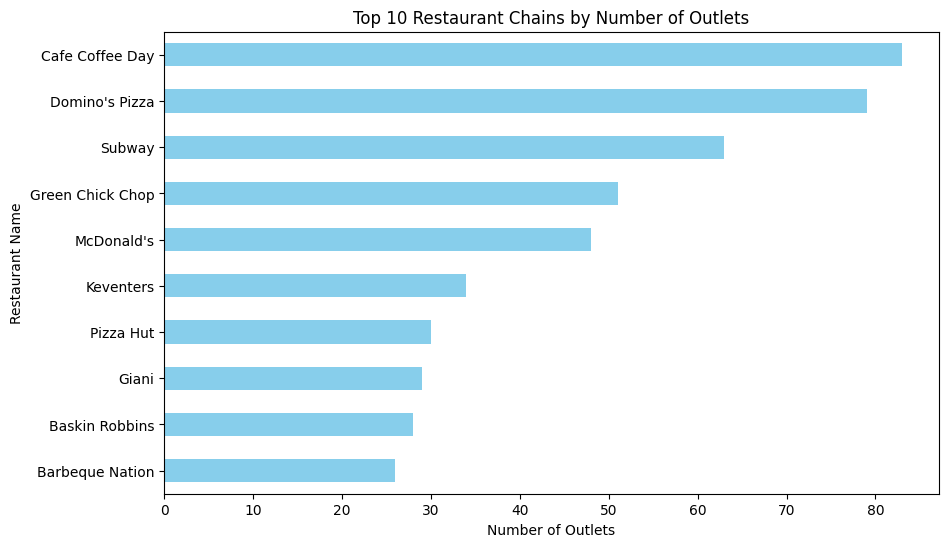

In [21]:
plt.figure(figsize=(10,6))
chains.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Restaurant Chains by Number of Outlets')
plt.xlabel('Number of Outlets')
plt.gca().invert_yaxis()
plt.show()

In [22]:
rating_comparison = df.groupby('Is Chain')['Aggregate rating'].mean()
print(rating_comparison)

Is Chain
False    2.614109
True     2.789926
Name: Aggregate rating, dtype: float64


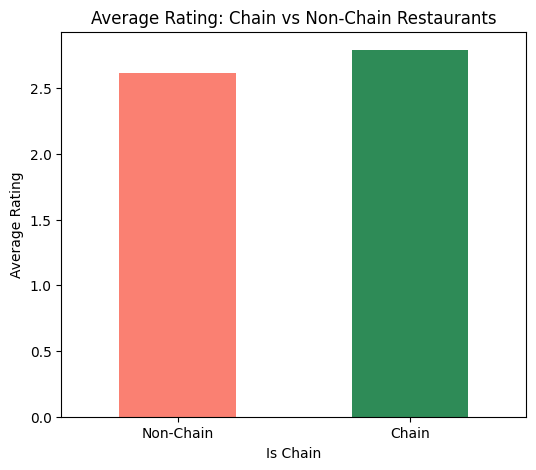

In [23]:
plt.figure(figsize=(6,5))
rating_comparison.plot(kind='bar', color=['salmon', 'seagreen'])
plt.xticks([0,1], ['Non-Chain', 'Chain'], rotation=0)
plt.title('Average Rating: Chain vs Non-Chain Restaurants')
plt.ylabel('Average Rating')
plt.show()

Is Chain
False    147.196216
True     179.874604
Name: Votes, dtype: float64


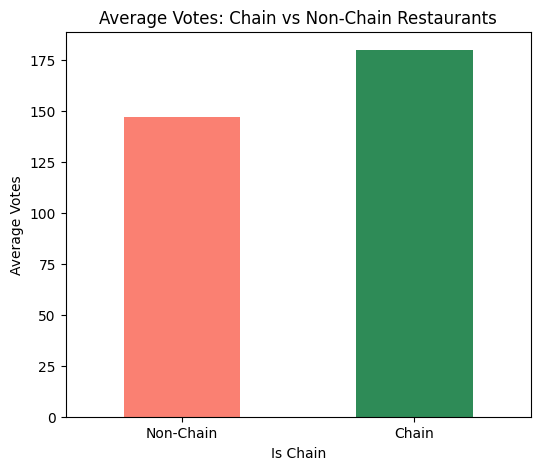

In [24]:
votes_comparison = df.groupby('Is Chain')['Votes'].mean()
print(votes_comparison)

plt.figure(figsize=(6,5))
votes_comparison.plot(kind='bar', color=['salmon', 'seagreen'])
plt.xticks([0,1], ['Non-Chain', 'Chain'], rotation=0)
plt.title('Average Votes: Chain vs Non-Chain Restaurants')
plt.ylabel('Average Votes')
plt.show()

In [25]:
top_rated_chains = df[df['Is Chain']].groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
print("Top 10 highest rated chains:")
print(top_rated_chains)

Top 10 highest rated chains:
Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Garota de Ipanema            4.600
Dishoom                      4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


In [26]:
top_voted_chains = df[df['Is Chain']].groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=False).head(10)
print("Top 10 most popular chains by total votes:")
print(top_voted_chains)

Top 10 most popular chains by total votes:
Restaurant Name
Barbeque Nation              28142
AB's - Absolute Barbecues    13400
Big Chill                    10853
Farzi Cafe                   10098
Truffles                      9682
Chili's                       8156
Joey's Pizza                  7807
Big Yellow Door               7511
Saravana Bhavan               7238
Starbucks                     7139
Name: Votes, dtype: int64


In [27]:
print("Summary:")
print(f"- Total restaurant chains identified: {len(chains)}")
print(f"- Average rating - Chain: {rating_comparison[True]:.2f} | Non-Chain: {rating_comparison[False]:.2f}")
print(f"- Average votes - Chain: {votes_comparison[True]:.2f} | Non-Chain: {votes_comparison[False]:.2f}")
print(f"- Most widespread chain: {chains.index[0]} ({chains.iloc[0]} outlets)")

Summary:
- Total restaurant chains identified: 734
- Average rating - Chain: 2.79 | Non-Chain: 2.61
- Average votes - Chain: 179.87 | Non-Chain: 147.20
- Most widespread chain: Cafe Coffee Day (83 outlets)
